# German Credit Risk

Goal: predict whether a person who applies for credit is a **good** or **bad** credit risk, and find which features drive that risk.

Outline:
1. Data loading
2. Data preparation and exploration
3. The three most significant features
4. Modelling
5. Validation and evaluation
6. Conclusions

In [1]:
import os
import warnings
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_STATE = 42  # used everywhere so results are repeatable
sns.set_theme(style="whitegrid")

# The baseline never predicts "bad", so its precision is undefined; it is reported as 0
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
# kagglehub's progress bar warns when ipywidgets is missing; the download works without it
warnings.filterwarnings("ignore", message="IProgress not found")

## 1. Data loading

The dataset is downloaded from Kaggle ([btolar1/weka-german-credit](https://www.kaggle.com/btolar1/weka-german-credit)) with `kagglehub`.

In [3]:
KAGGLE_DATASET = "btolar1/weka-german-credit"
DATA_FILE = "credit-g.csv"
LOCAL_PATH = os.path.join("data", DATA_FILE)


def load_credit_data():
    """Download the dataset from Kaggle, or use the local copy if the download fails."""
    try:
        dataset_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_path = os.path.join(dataset_dir, DATA_FILE)
    except Exception as error:
        print(f"Kaggle download failed ({error}), using local copy.")
        csv_path = LOCAL_PATH
    return pd.read_csv(csv_path)


df = load_credit_data()

# Some column names in the raw file have leading spaces
df.columns = df.columns.str.strip()

print(df.shape)
df.head()

(1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


## 2. Data preparation and exploration

### 2.1 Data quality

In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.info()

Missing values: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   checking_status         1000 non-null   str  
 1   duration                1000 non-null   int64
 2   credit_history          1000 non-null   str  
 3   purpose                 1000 non-null   str  
 4   credit_amount           1000 non-null   int64
 5   savings_status          1000 non-null   str  
 6   employment              1000 non-null   str  
 7   installment_commitment  1000 non-null   int64
 8   personal_status         1000 non-null   str  
 9   other_parties           1000 non-null   str  
 10  residence_since         1000 non-null   int64
 11  property_magnitude      1000 non-null   str  
 12  age                     1000 non-null   int64
 13  other_payment_plans     1000 non-null   str  
 14  housing                 1000 non-null   str  
 1

In [5]:
TARGET = "class"

numeric_features = df.drop(columns=TARGET).select_dtypes("number").columns.tolist()
categorical_features = df.drop(columns=TARGET).select_dtypes(exclude="number").columns.tolist()

print(f"{len(numeric_features)} numeric:", numeric_features)
print(f"{len(categorical_features)} categorical:", categorical_features)

7 numeric: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
13 categorical: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


The data is clean: there are no missing values and no duplicate rows, so nothing needs to be filled in or removed. There are 7 numeric and 13 categorical (text) features. The categorical features are turned into numbers inside the model pipeline (section 4).

### 2.2 Target balance

class
good    0.7
bad     0.3
Name: proportion, dtype: float64


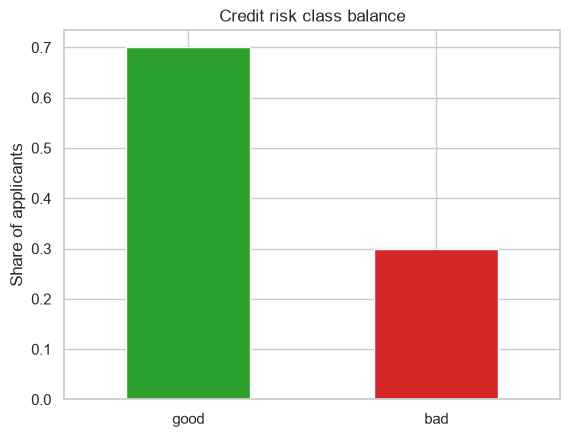

In [6]:
class_share = df[TARGET].value_counts(normalize=True)
print(class_share)

ax = class_share.plot(kind="bar", color=["tab:green", "tab:red"], rot=0)
ax.set(title="Credit risk class balance", ylabel="Share of applicants", xlabel="")
plt.show()

The classes are not balanced: 70% of applicants are good and 30% are bad. A model that always says "good" would already be 70% accurate without learning anything, so accuracy on its own would be misleading. Instead we use:
- **ROC-AUC**: how well the model ranks bad applicants above good ones (0.5 = guessing, 1.0 = perfect).
- **Recall** for the bad class: of all the bad applicants, how many the model catches.
- **Precision** for the bad class: of all the applicants the model flags as bad, how many really are bad.

Every split is *stratified*, which means each part keeps the same 70/30 mix of good and bad applicants.

> **Decision: judge models by ROC-AUC, recall and precision for the bad class, not by accuracy**
>
> **Why:** Catching bad applicants is the main goal. Accuracy hides whether we actually do that.
>
> **Pros**
> - ROC-AUC doesn't depend on where we set the cut-off between "good" and "bad".
> - Recall tells us directly how many bad applicants we catch.
>
> **Cons**
> - These metrics are harder for non-technical readers to follow than accuracy.
> - Catching more bad applicants (higher recall) usually means wrongly flagging more good ones (lower precision), so we need a way to balance the two. Section 5.3 uses the business cost for this.
>
> **Alternatives considered**
> - *Accuracy*: gives the "always good" model 70%, so it can't show whether we catch bad applicants.
> - *F1 score*: a single number that combines precision and recall, but it treats both kinds of mistake as equally bad, which isn't true for a bank.
> - *Precision-recall AUC*: designed for data where one class is very rare. Here 30% are bad, which isn't rare, and ROC-AUC is better known.
> - These metrics are for comparing models. For the business decision we add one simple cost metric in section 5.3.

### 2.3 Numeric features by class

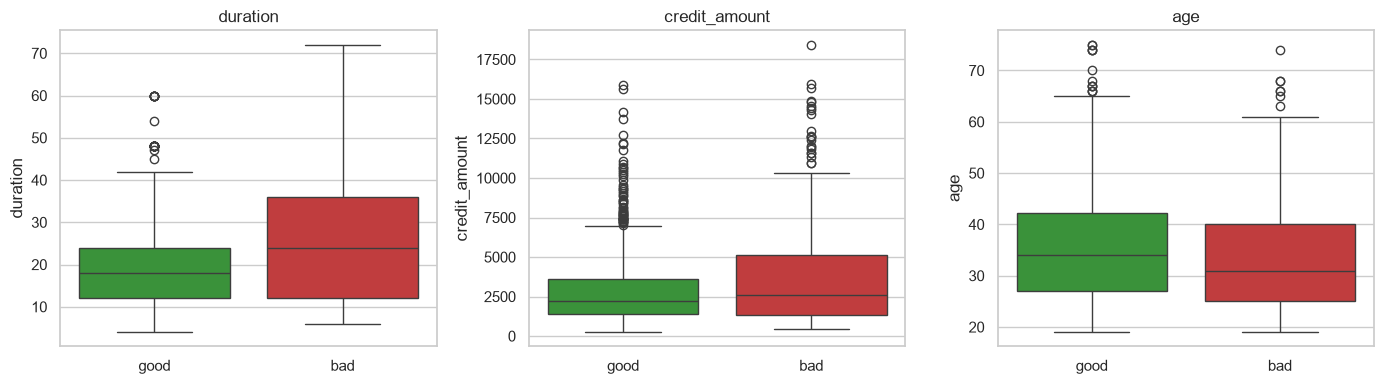

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feature in zip(axes, ["duration", "credit_amount", "age"]):
    sns.boxplot(data=df, x=TARGET, y=feature, hue=TARGET, ax=ax,
                palette={"good": "tab:green", "bad": "tab:red"})
    ax.set(title=feature, xlabel="")
plt.tight_layout()
plt.show()

**How to read the box plots:** the line in the middle of each box is the typical (median) applicant. The box holds the middle half of the applicants, the whiskers show the normal range, and the dots are unusual applicants (for example a few very large loans). These are real loans, not errors, so we keep them.

- **Duration**: a typical good loan runs about 18 months, a typical bad loan about 24 months, and bad loans often run much longer. **Longer loans are riskier.**
- **Credit amount**: typical amounts are close (about 2,200 for good and 2,600 for bad), but bad loans are more often large. **Bigger loans are a bit riskier.**
- **Age**: a typical good applicant is about 34 and a typical bad applicant about 31. **Younger applicants are slightly riskier**, but the difference is small.

The green and red boxes overlap a lot in all three charts, so no single feature can separate good from bad applicants on its own. That is why we need a model that combines all the features.

### 2.4 Categorical features: share of bad applicants in each category

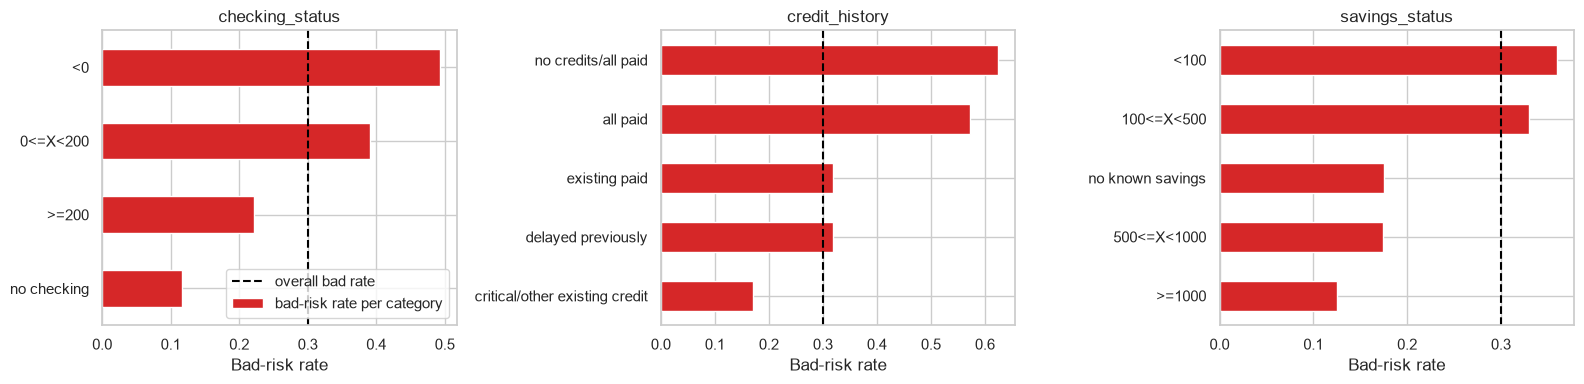

In [8]:
overall_bad_rate = (df[TARGET] == "bad").mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feature in zip(axes, ["checking_status", "credit_history", "savings_status"]):
    bad_rate = (df[TARGET] == "bad").groupby(df[feature]).mean().sort_values().rename("bad-risk rate per category")
    bad_rate.plot(kind="barh", ax=ax, color="tab:red")
    ax.axvline(overall_bad_rate, color="black", linestyle="--", label="overall bad rate")
    ax.set(title=feature, xlabel="Bad-risk rate", ylabel="")
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

**How to read the charts:** each bar shows the share of applicants in that category who turned out to be bad risks. The dashed line is the overall bad rate (30%). A bar to the right of the line means the category is riskier than average; a bar to the left means it is safer. Amounts are in Deutsche Mark (DM), the currency of the original data.

- **Checking account status** (balance in the applicant's current account at this bank): the clearest pattern. About half of applicants with a negative balance (`<0`) are bad, against 39% for a low balance (0–200 DM), 22% for 200 DM or more, and only 12% for applicants with no checking account at this bank. **The less money in the account, the higher the risk.**
- **Savings**: the same pattern. Applicants with under 100 DM in savings are bad 36% of the time, against 12% for 1000 DM or more. **More savings means lower risk.** "No known savings" is surprisingly low risk (17%), probably because these people keep their savings at another bank.
- **Credit history**: this one is surprising. Applicants whose history says "critical / other existing credit" have the *lowest* bad rate (17%), while "all paid" and "no credits / all paid" have the *highest* (57–62%). A likely reason is that the bank already screened applicants with a poor history very strictly, so the few who got a loan were strong in other ways. These two high-risk groups are also small (49 and 40 applicants), so their rates are less reliable.

**In short:** how much money applicants hold (in their checking and savings accounts) is a strong sign of risk. Credit history matters too, but not in the way you would expect, which is a good reason to let the model learn the patterns from the data rather than guessing them.

### 2.5 Train/test split

We put aside 20% of the data as a test set and don't touch it until the final evaluation. All feature analysis and model choices use only the training set. That way nothing from the test set "leaks" into the model and makes the final score look better than it really is.

> **Decision: stratified 80/20 train/test split**
>
> **Why:** We need data the model has never seen to get an honest idea of how it will perform on new applicants.
>
> **Pros**
> - Gives a fair final score.
> - Stratifying keeps the 70/30 good/bad mix in both parts.
>
> **Cons**
> - With only 1000 rows, the test set has 200 applicants (60 bad), so the test score can move quite a bit by chance.
> - 20% of the data isn't used for training.
>
> **Alternatives considered**
> - *Cross-validation only, no test set*: uses all the data, but the model would be chosen and scored on the same data, which makes it look better than it is.
> - *Nested cross-validation*: the most thorough option, but more than we need because we hardly tune any settings.
> - *Split by date*: the data has no dates.

In [9]:
X = df.drop(columns=TARGET)
y = (df[TARGET] == "bad").astype(int)  # 1 = bad risk, the class we want to catch

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (800, 20) Test: (200, 20)


## 3. The three most significant features

We use **mutual information**. It measures how much knowing a feature tells us about whether an applicant is good or bad (0 means it tells us nothing). It doesn't depend on any model, works for both numeric and categorical features, and also finds relationships that aren't straight lines. Section 5.4 checks the result against what the model itself relies on (permutation importance).

> **Decision: use mutual information to rank features**
>
> **Why:** It treats numeric and categorical features the same way and doesn't depend on any model.
>
> **Pros**
> - Model-free, so the ranking doesn't favour one algorithm.
> - Finds curved (not straight-line) relationships that correlation would miss.
>
> **Cons**
> - Looks at each feature on its own, so it ignores overlap between features (for example, longer loans are usually also larger loans).
> - Scores for numeric features are less reliable on a small dataset, which is why section 5.4 checks the ranking with a second method.
>
> **Alternatives considered**
> - *Chi-squared test*: only for categorical features, so numeric ones would first need to be grouped into bands. It tells us whether a relationship exists, not how strong it is.
> - *Correlation*: only for numeric features, and only finds straight-line relationships.
> - *Model-based importance (coefficients, tree importance)*: depends on the chosen model. We use it as a second opinion in section 5.4 instead.
> - *SHAP values*: richer explanations, but needs an extra package and is more than this question needs.

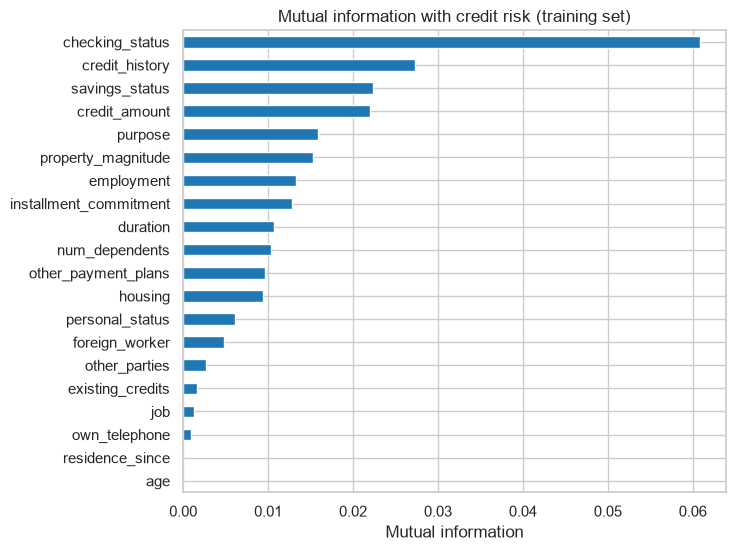

Top 3 features: ['checking_status', 'credit_history', 'savings_status']


In [10]:
# mutual_info_classif needs numbers, so each category is replaced by a code (the order doesn't matter here)
X_train_encoded = X_train.copy()
X_train_encoded[categorical_features] = OrdinalEncoder().fit_transform(X_train[categorical_features])

mutual_info = pd.Series(
    mutual_info_classif(X_train_encoded, y_train,
                        discrete_features=X_train.columns.isin(categorical_features),
                        random_state=RANDOM_STATE),
    index=X_train.columns,
).sort_values()

ax = mutual_info.plot(kind="barh", figsize=(7, 6), color="tab:blue")
ax.set(title="Mutual information with credit risk (training set)", xlabel="Mutual information")
plt.show()

print("Top 3 features:", mutual_info.nlargest(3).index.tolist())

`checking_status` is by far the most informative feature. `credit_history`, `savings_status` and `credit_amount` follow with very similar scores, so the order after first place is not clear. Because mutual information looks at one feature at a time, section 5.5 combines it with the model's permutation importance to decide the final top 3.

## 4. Modelling

Each model is a single scikit-learn `Pipeline`, which joins the data preparation steps and the model together. This means the preparation is learned from the training data only, including inside each cross-validation fold. The preparation steps are:
- numeric features are **standardised** (rescaled to mean 0 and standard deviation 1), so they are all on the same scale
- categorical features are **one-hot encoded** (one 0/1 column per category). `drop="first"` drops one column per feature, because its value can be worked out from the others

We compare three models:
- **Baseline**: always predicts the most common class ("good"). Any real model must beat it.
- **Logistic regression**: simple, fast and easy to explain.
- **Random forest**: many decision trees voting together. It can find more complex patterns.

`class_weight="balanced"` tells the models to give more weight to the smaller **bad** class, so they don't just ignore it.

> **Decision: pipelines with scaling, one-hot encoding (`drop="first"`) and `class_weight="balanced"`**
>
> **Why:** Every step is repeatable, and the test data can never influence how the data is prepared.
>
> **Pros**
> - No leakage: the test data never influences the preparation steps.
> - `drop="first"` removes duplicate information and makes the logistic regression coefficients easier to read.
> - Class weighting helps the model notice the smaller bad class without making up new applicants (as SMOTE would).
>
> **Cons**
> - One-hot encoding creates many columns. That's fine here, but wouldn't work well for features with hundreds of categories.
> - Class weighting makes the model say "bad" more often, so more good applicants get rejected.
> - The random forest doesn't need scaling, but it does no harm.
>
> **Alternatives considered**
> - *SMOTE oversampling*: creates artificial applicants, needs an extra package (`imbalanced-learn`), and must be done carefully inside each fold. Class weighting gets a similar effect with one setting.
> - *Undersampling the good class*: throws away data when we only have 1000 rows.
> - *Ordinal or target encoding*: ordinal encoding adds an order that doesn't exist (for example in `purpose`), and target encoding needs extra care to avoid leakage. With only a few categories per feature, one-hot encoding is the safe choice.

> **Decision: compare a baseline, logistic regression and random forest**
>
> **Why:** Comparing a simple model with a more flexible one shows whether the extra complexity is worth it. The baseline shows whether either model learned anything at all.
>
> **Pros**
> - Covers both simple and more complex patterns.
> - Both models are well known and quick to train.
>
> **Cons**
> - We don't tune the model settings, to keep things simple, so the random forest might do slightly better with tuning.
> - Other models (such as gradient boosting) might score a little higher, but are more complex.
>
> **Alternatives considered**
> - *Gradient boosting (XGBoost, LightGBM)*: often the strongest on table data, but needs tuning, and on 1000 rows it rarely beats a random forest by much.
> - *Single decision tree*: very easy to explain, but unstable on small data (small changes in the data give a very different tree).
> - *SVM or neural network*: harder to explain, and not expected to do better on a small table of data.
> - *Traditional credit scorecard*: the standard in banking, but needs features to be grouped into bands by hand. Our logistic regression is close to it in spirit.

In [11]:
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                            class_weight="balanced", random_state=RANDOM_STATE),
}
pipelines = {name: Pipeline([("preprocess", preprocessor), ("model", model)])
             for name, model in models.items()}

## 5. Validation and evaluation

### 5.1 Cross-validation on the training set

5-fold stratified cross-validation splits the training data into 5 parts (folds). Each model is trained on 4 parts and scored on the fifth, and this is repeated so every part is scored once. This gives five scores instead of one, so we can see both the average performance and how much it varies.

> **Decision: 5-fold stratified cross-validation to compare models**
>
> **Why:** A single split can be lucky or unlucky. Five folds give a more reliable average and show how much the score moves.
>
> **Pros**
> - A more reliable comparison between models.
> - The standard deviation shows whether a difference between models is real or just chance.
>
> **Cons**
> - Training takes five times longer (only seconds on this data).
> - Still only an estimate, since each fold has just 160 applicants.
>
> **Alternatives considered**
> - *10-fold*: more training data per fold, but each scoring fold has only 80 applicants (24 bad), so each score is less reliable.
> - *Leave-one-out*: 800 model fits, and the result still varies a lot.
> - *Repeated 5-fold*: a more stable estimate. A sensible upgrade, but not needed here.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["roc_auc", "recall", "precision", "f1"]

cv_results = {}
for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}
    cv_results[name]["roc_auc_std"] = scores["test_roc_auc"].std()

pd.DataFrame(cv_results).T.round(3)

,roc_auc,recall,precision,f1,roc_auc_std
Baseline,0.500,0.000,0.000,0.000,0.000
Logistic regression,0.773,0.688,0.508,0.583,0.053
Random forest,0.791,0.700,0.520,0.597,0.040


Both models clearly beat the baseline (ROC-AUC around 0.77–0.79 against 0.50). The random forest scores slightly higher, but the gap (about 0.02) is smaller than how much the score moves between folds (`roc_auc_std`, about 0.04–0.05). So the difference could just be chance.

**Model choice: logistic regression.** Once chance is taken into account it performs just as well, and it is simpler and easier to explain to the business, which matters for credit decisions. We keep the random forest to compare on the test set.

> **Decision: choose logistic regression over random forest**
>
> **Why:** The scores are effectively tied, so the simpler, easier-to-explain model wins.
>
> **Pros**
> - Each decision is easy to explain to customers and regulators, which matters in lending.
> - Less likely to overfit (learn noise instead of real patterns) on a small dataset.
> - Fast and stable.
>
> **Cons**
> - Doesn't find combinations of features on its own (for example "young *and* a large loan").
> - The random forest might pull ahead with more data or tuning.
>
> **Alternatives considered**
> - *Pick the highest score (random forest)*: the gap is within chance, and the model is harder to explain.
> - *Combine both models*: more complexity for no clear gain.

### 5.2 Final evaluation on the held-out test set

In [13]:
for pipeline in pipelines.values():
    pipeline.fit(X_train, y_train)

fitted_models = {name: pipeline for name, pipeline in pipelines.items() if name != "Baseline"}

for name, pipeline in fitted_models.items():
    test_roc_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
    print(f"=== {name}: test ROC-AUC {test_roc_auc:.3f} ===")
    print(classification_report(y_test, pipeline.predict(X_test), target_names=["good", "bad"]))

=== Logistic regression: test ROC-AUC 0.807 ===
              precision    recall  f1-score   support

        good       0.89      0.73      0.80       140
         bad       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200

=== Random forest: test ROC-AUC 0.793 ===
              precision    recall  f1-score   support

        good       0.85      0.73      0.78       140
         bad       0.53      0.70      0.60        60

    accuracy                           0.72       200
   macro avg       0.69      0.71      0.69       200
weighted avg       0.75      0.72      0.73       200



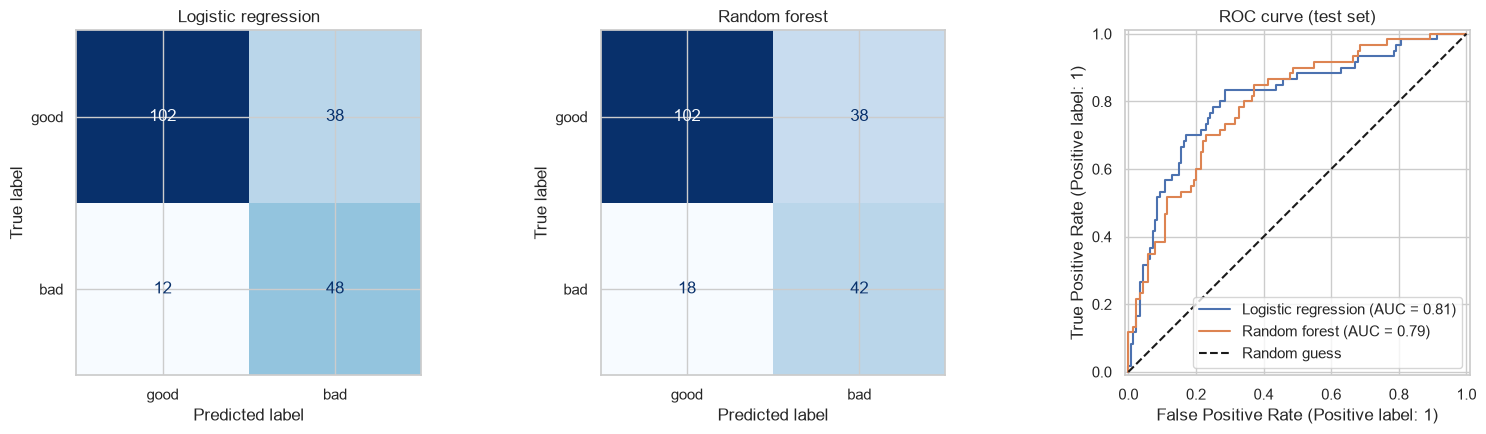

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, pipeline) in zip(axes, fitted_models.items()):
    ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, display_labels=["good", "bad"],
                                          cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)

for name, pipeline in fitted_models.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, name=name, ax=axes[2])
axes[2].plot([0, 1], [0, 1], "k--", label="Random guess")
axes[2].set_title("ROC curve (test set)")
axes[2].legend()

plt.tight_layout()
plt.show()

### 5.3 A metric for the business: cost saved compared with approving everyone

ROC-AUC and recall help us compare models, but they don't tell a manager whether to use one. For that decision we report one number:

**Cost saved (%) = 1 − (cost of the model's mistakes ÷ cost of approving every applicant)**

- *Approving everyone* is what happens with no screening at all. This is exactly what the baseline model does.
- Mistakes are priced with the cost table that comes with the dataset: approving a bad applicant costs **5**, rejecting a good applicant costs **1**.
- 0% means the model is no better than no screening. 100% means it makes no costly mistakes at all.

Next to it we show how many of each kind of mistake the model makes on the 200 test applicants, so the trade-off is concrete: how many bad loans get through, and how many good customers are turned away.

On time: the model scores an application instantly. The data doesn't say how long a manual review takes, so we can't put a number on the time saved. If the bank provides that figure, the counts below can be turned into review hours.

> **Decision: "cost saved compared with approving everyone" as the business metric**
>
> **Why:** It answers the business question directly ("how much does this model save us?") in a way anyone can read, and it reflects that the two kinds of mistake have different costs.
>
> **Pros**
> - A percentage is easy to compare across models and across test sets of any size.
> - Based on the cost table that comes with the dataset, not a number we made up.
>
> **Cons**
> - The 5-to-1 cost ratio comes from the dataset's documentation. A real bank should use its own figures.
> - It is a relative saving, not an amount of money.
>
> **Alternatives considered**
> - *Accuracy, ROC-AUC or F1 for stakeholders*: abstract, and they don't say what a decision costs.
> - *Profit in money*: the best option if we knew the bank's loan margins and how much it loses when a customer doesn't repay, but the data doesn't include them.
> - *Total cost*: grows with the number of applicants scored, so it can't be compared between test sets of different sizes.

In [15]:
COST_FALSE_GOOD = 5  # predicted good, actually bad: the loan may not be repaid
COST_FALSE_BAD = 1   # predicted bad, actually good: a lost customer


def business_summary(y_true, y_pred):
    """Count both kinds of mistake and the cost saved compared with approving everyone."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    model_cost = fn * COST_FALSE_GOOD + fp * COST_FALSE_BAD
    approve_everyone_cost = (fn + tp) * COST_FALSE_GOOD  # every bad applicant gets a loan
    return {
        "bad loans approved": fn,
        "good customers rejected": fp,
        "cost saved (%)": round(100 * (1 - model_cost / approve_everyone_cost), 1),
    }


pd.DataFrame({name: business_summary(y_test, pipeline.predict(X_test))
              for name, pipeline in pipelines.items()}).T

,bad loans approved,good customers rejected,cost saved (%)
Baseline,60.0,0.0,0.0
Logistic regression,12.0,38.0,67.3
Random forest,18.0,38.0,57.3


With the default cut-off (reject when the predicted risk of "bad" is above 0.5), logistic regression saves **67%** of the cost of approving everyone, against 57% for the random forest. Out of 200 test applicants it lets **12 bad loans** through (instead of 60 with no screening), but turns away **38 good customers**. Because approving a bad applicant costs five times more than rejecting a good one, that trade is worth it.

### 5.4 Which features does the model rely on?

**Permutation importance** shuffles the values of one feature at a time on the test set, which breaks that feature's link with the outcome, and measures how much the ROC-AUC drops. A big drop means the model depends heavily on that feature. This checks the mutual information ranking from section 3.

> **Decision: permutation importance on the test set**
>
> **Why:** It shows which features the chosen model actually uses, on data it hasn't seen.
>
> **Pros**
> - Works with any model, and scores each original feature as a whole rather than each one-hot column.
> - Measured on unseen data, so it reflects real predictive value.
>
> **Cons**
> - If two features carry the same information, shuffling one barely hurts because the model can lean on the other. So both can look less important than they really are.
> - Results depend on the model and change a little with each random shuffle (we average 20 repeats).
>
> **Alternatives considered**
> - *Logistic regression coefficients*: one per one-hot column rather than one per feature, and only comparable because the numeric features are scaled.
> - *Random forest's built-in importance*: favours numeric features and features with many categories, and is measured on training data.
> - *SHAP values*: can also explain single applicants, but need an extra package. A good next step if the bank needs to explain individual decisions.

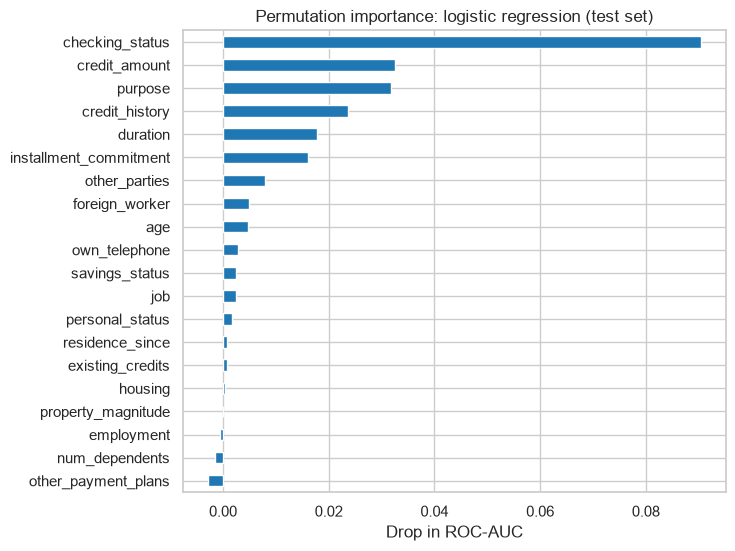

Top 3 features: ['checking_status', 'credit_amount', 'purpose']


In [16]:
best_model = pipelines["Logistic regression"]

importance = permutation_importance(best_model, X_test, y_test, scoring="roc_auc",
                                    n_repeats=20, random_state=RANDOM_STATE)
permutation_scores = pd.Series(importance.importances_mean, index=X_test.columns).sort_values()

ax = permutation_scores.plot(kind="barh", figsize=(7, 6), color="tab:blue")
ax.set(title="Permutation importance: logistic regression (test set)", xlabel="Drop in ROC-AUC")
plt.show()

print("Top 3 features:", permutation_scores.nlargest(3).index.tolist())

### 5.5 Final top 3 features

We combine the two methods by averaging each feature's rank. A feature counts as significant only if it ranks high on both, which is more reliable than trusting either method alone.

> **Decision: average the two rankings**
>
> **Why:** The two methods agree on first place but not on the order after that. Averaging picks the features that are strong on both.
>
> **Pros**
> - More reliable than trusting one method.
> - Simple and easy to follow.
>
> **Cons**
> - Ranks ignore how big the gaps between features are.
> - Ties are possible (here `credit_amount` and `credit_history` share second place).
>
> **Alternatives considered**
> - *Trust one method only*: each has the weak spots listed above.
> - *Average the raw scores*: the two methods use different scales, so the scores would first need converting to a common scale. Ranks avoid that.

In [17]:
feature_ranks = pd.DataFrame({
    "mutual_information_rank": mutual_info.rank(ascending=False),
    "permutation_importance_rank": permutation_scores.rank(ascending=False),
})
feature_ranks["average_rank"] = feature_ranks.mean(axis=1)
feature_ranks.sort_values("average_rank").head(6)

,mutual_information_rank,permutation_importance_rank,average_rank
checking_status,1.0,1.0,1.0
credit_amount,4.0,2.0,3.0
credit_history,2.0,4.0,3.0
purpose,5.0,3.0,4.0
installment_commitment,8.0,6.0,7.0
duration,9.0,5.0,7.0


The three most significant features driving credit risk are:

1. **`checking_status`**: ranked first by both methods, by a wide margin. Applicants with a negative or low checking balance are much riskier than those with no checking account at this bank.
2. **`credit_amount`**: larger loans are riskier.
3. **`credit_history`**: how people repaid in the past predicts how they will repay in future.

`purpose` comes next. `duration` looked important in the exploration, but it goes hand in hand with credit amount (bigger loans usually run longer). Once the model knows the amount, duration adds little extra.

## 6. Conclusions

- **Data**: 1000 applicants, no missing values, 70% good and 30% bad. Stratified splits and class weighting deal with the imbalance.
- **Key drivers**: checking account status, credit amount and credit history.
- **Model**: logistic regression inside a scikit-learn pipeline. It scores about 0.77 ROC-AUC in cross-validation and about 0.81 on the test set, and catches 80% of bad applicants. It performs as well as a random forest while being simpler and easier to explain.
- **Business metric**: *cost saved compared with approving everyone*. The model saves about **two-thirds** of that cost (67% on the test set). Out of 200 test applicants it lets 12 bad loans through instead of 60, and turns away 38 good customers.

**Possible next steps**
- Replace the 5-to-1 cost ratio with the bank's real costs, and the time a manual review takes, so the savings can be shown in money and hours.
- With real costs, move the cut-off (currently a predicted risk of 0.5) to the point that saves the most.
- Gather more data: with 1000 rows all the scores move quite a bit by chance (see the cross-validation standard deviations).